# Regresion Lineal Multivariable
## Prediccion de Jugadores (Plays) - Backloggd Games Dataset

En este ejercicio implementaremos la regresion lineal multivariable para predecir
el numero de jugadores (`Plays`) de un videojuego a partir de sus caracteristicas.

Se implementaran dos metodos:
1. **Descenso por el gradiente**
2. **Ecuacion normal**



In [ ]:
# Utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficacion (trazado de graficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# Llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

# Modulo para parseo de CSV y expresiones regulares
import csv
import re

print('Librerias cargadas correctamente.')


Librerias cargadas correctamente.


## Parte 1: Montar Google Drive y cargar el dataset

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

CSV_PATH = '/content/gdrive/MyDrive/Universida/IA/Dataset/backloggd_games.csv'

Mounted at /content/gdrive


## Parte 2: Funciones de parseo

El dataset contiene valores en notacion `K` (miles) y `M` (millones),
por ejemplo `21K` o `1.5M`. Se implementan funciones para convertirlos a `float`.

In [ ]:
def parse_kilo(val):
    """
    Convierte strings como '21K', '1.5M' o '300' a float.
    Retorna None si el valor no es parseable.
    """
    if val is None or str(val).strip() == '':
        return None
    val = str(val).strip().replace(',', '')
    m = re.match(r'([\d.]+)\s*([KkMm]?)', val)
    if not m:
        return None
    num = float(m.group(1))
    suffix = m.group(2).upper()
    if suffix == 'K':   return num * 1_000
    elif suffix == 'M': return num * 1_000_000
    return num


def parse_year(date_str):
    """
    Extrae el anio de strings como '25-feb-22' o '2022-02-25'.
    Retorna None si no puede extraerlo.
    """
    if not date_str:
        return None
    m = re.search(r'-(\d{2})$', date_str.strip())
    if m:
        yy = int(m.group(1))
        return 2000 + yy if yy <= 30 else 1900 + yy
    m = re.search(r'\b(19|20)\d{2}\b', date_str)
    return int(m.group(0)) if m else None


def count_list_items(cell):
    """Cuenta elementos en strings tipo ['A', 'B', 'C']."""
    return len(re.findall(r"'([^']+)'", str(cell)))


def has_genre(cell, genre):
    """Devuelve 1 si el genero esta presente en la celda, 0 si no."""
    return 1 if genre.lower() in str(cell).lower() else 0


print('Funciones de parseo definidas.')

Funciones de parseo definidas.


## Parte 3: Carga y preparacion de datos

In [ ]:
TOP_GENRES = ['RPG', 'Adventure', 'Shooter', 'Action', 'Strategy',
              'Simulation', 'Sports', 'Puzzle', 'Platform', 'Fighting']

rows    = []
titles  = []
skipped = 0

with open(CSV_PATH, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            plays    = parse_kilo(row.get('Plays', ''))
            rating   = float(row['Rating']) if row.get('Rating','').strip() else None
            playing  = parse_kilo(row.get('Playing', ''))
            backlogs = parse_kilo(row.get('Backlogs', ''))
            wishlist = parse_kilo(row.get('Wishlist', ''))
            lists    = parse_kilo(row.get('Lists', ''))
            reviews  = parse_kilo(row.get('Reviews', ''))
            year     = parse_year(row.get('Release_Date', ''))
            n_plat   = count_list_items(row.get('Platforms', ''))
            n_gen    = count_list_items(row.get('Genres', ''))
            g_flags  = [has_genre(row.get('Genres',''), g) for g in TOP_GENRES]

            if any(v is None for v in [plays, rating, playing, backlogs,
                                        wishlist, lists, reviews, year]):
                skipped += 1
                continue

            rows.append([plays, rating, playing, backlogs, wishlist,
                         lists, reviews, year, n_plat, n_gen] + g_flags)
            titles.append(row.get('Title', 'Unknown'))

        except (ValueError, KeyError):
            skipped += 1

# Convertir a array NumPy
data = np.array(rows, dtype=np.float64)

FEATURE_NAMES = (
    ['Rating', 'Playing', 'Backlogs', 'Wishlist', 'Lists',
     'Reviews', 'Release_Year', 'Num_Platforms', 'Num_Genres']
    + ['Genre_' + g for g in TOP_GENRES]
)

# Variable objetivo y features
X = data[:, 1:]   # todas las columnas excepto Plays
y = data[:, 0]    # columna Plays
y = np.log1p(y)
m = y.size        # numero de ejemplos de entrenamiento

print('Ejemplos cargados: {}'.format(m))
print('Filas omitidas:    {}'.format(skipped))
print('Numero de features: {}'.format(X.shape[1]))
print()
print('{:>10s}{:>10s}{:>10s}{:>12s}'.format('Rating','Playing','Backlogs','Plays (y)'))
print('-' * 44)
for i in range(10):
    print('{:10.1f}{:10.0f}{:10.0f}{:12.0f}'.format(
        X[i,0], X[i,1], X[i,2], y[i]))

Ejemplos cargados: 24853
Filas omitidas:    35147
Numero de features: 19

    Rating   Playing  Backlogs   Plays (y)
--------------------------------------------
       4.5      4100      5600          10
       4.4      3100      5600          10
       4.3      3500      7300          10
       4.4      2700      9600          10
       4.2       728      5700          10
       4.3      2100      1300          11
       4.1      1200      5300           9
       4.6      4600      3000           8
       4.6       908      2100           9
       4.3      1300      7200          10


## Parte 4: Normalizacion de features

Cuando los features tienen escalas muy diferentes (ej: `Rating` va de 0 a 5
mientras que `Playing` puede ser miles), el descenso por gradiente converge
muy lentamente. La normalizacion soluciona esto.

$$x_i := \\frac{x_i - \\mu_i}{\\sigma_i}$$

In [ ]:
def featureNormalize(X):
    """
    Normaliza los features de X.
    Retorna:
        X_norm  -- X normalizado
        mu      -- media de cada feature
        sigma   -- desviacion estandar de cada feature
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)

    # Evitar division por cero en features constantes
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


# Llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (mu):')
for i, name in enumerate(FEATURE_NAMES):
    print('  {:<20}: {:>12.4f}'.format(name, mu[i]))

print()
print('Desviacion estandar calculada (sigma):')
for i, name in enumerate(FEATURE_NAMES):
    print('  {:<20}: {:>12.4f}'.format(name, sigma[i]))

Media calculada (mu):
  Rating              :       3.0322
  Playing             :      15.1134
  Backlogs            :     128.2143
  Wishlist            :      62.8879
  Lists               :      69.1503
  Reviews             :      28.3547
  Release_Year        :    2009.8034
  Num_Platforms       :       2.5620
  Num_Genres          :       2.1290
  Genre_RPG           :       0.1888
  Genre_Adventure     :       0.3852
  Genre_Shooter       :       0.1661
  Genre_Action        :       0.0000
  Genre_Strategy      :       0.1482
  Genre_Simulation    :       0.0000
  Genre_Sports        :       0.0000
  Genre_Puzzle        :       0.1465
  Genre_Platform      :       0.1467
  Genre_Fighting      :       0.0649

Desviacion estandar calculada (sigma):
  Rating              :       0.7314
  Playing             :      94.2578
  Backlogs            :     433.0143
  Wishlist            :     227.3896
  Lists               :     211.9476
  Reviews             :     110.4246
  Release_Yea

In [ ]:
# Agrega el termino de interseccion a X
# (Columna de unos para theta_0)
X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('Shape de X con termino de sesgo: {}'.format(X_norm.shape))

Shape de X con termino de sesgo: (24853, 20)


## Parte 5: Funcion de costo y descenso por el gradiente

La funcion de costo para regresion lineal es:

$$J(\\theta) = \\frac{1}{2m} \\sum_{i=1}^{m} \\left( h_\\theta(x^{(i)}) - y^{(i)} \\right)^2$$

Y la regla de actualizacion del gradiente es:

$$\\theta_j := \\theta_j - \\alpha \\frac{1}{m} \\sum_{i=1}^{m} \\left( h_\\theta(x^{(i)}) - y^{(i)} \\right) x_j^{(i)}$$

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # Realiza una copia de theta, el cual sera actualizado por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


print('Funciones computeCostMulti y gradientDescentMulti definidas.')

Funciones computeCostMulti y gradientDescentMulti definidas.


## Parte 6: Ejecutar descenso por el gradiente

Se prueban distintos valores de `alpha` para comparar la velocidad de convergencia.

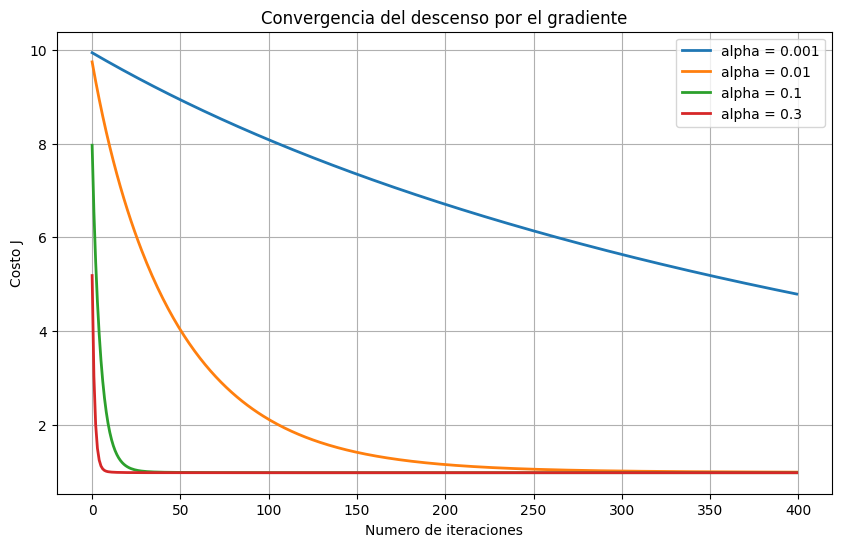

In [ ]:
# Elegir algunos valores para alpha (probar varias alternativas)
num_iters = 400
alphas    = [0.001, 0.01, 0.1, 0.3]

pyplot.figure(figsize=(10, 6))

for alpha in alphas:
    theta_init        = np.zeros(X_norm.shape[1])
    theta_tmp, J_hist = gradientDescentMulti(X_norm, y, theta_init, alpha, num_iters)
    pyplot.plot(np.arange(len(J_hist)), J_hist, lw=2, label='alpha = {}'.format(alpha))

pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

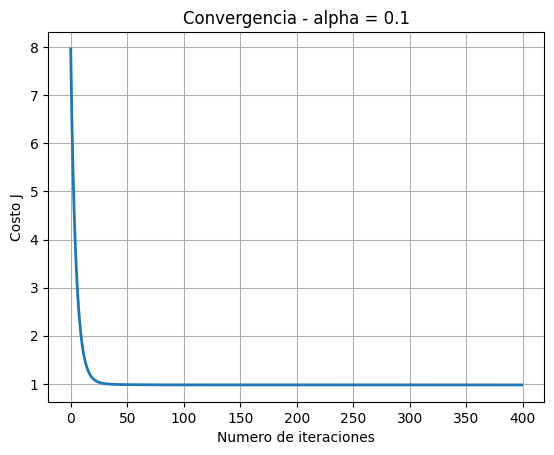

theta calculado por el descenso por el gradiente: [ 4.03912125e+00  2.89558300e-01 -3.91582687e-01  2.31356902e-01
 -8.76906888e-03  7.61656432e-01  3.09786117e-01 -1.43692572e-01
  3.56200625e-01 -8.64298522e-04  1.20769249e-01  9.62399282e-02
  1.13668294e-01  0.00000000e+00  5.33682735e-02  0.00000000e+00
  0.00000000e+00 -1.33768568e-02  1.12225923e-01  1.58641517e-01]


In [ ]:
# Elegir algun valor para alpha
alpha     = 0.1
num_iters = 400

# Inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_norm.shape[1])
theta, J_history = gradientDescentMulti(X_norm, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - alpha = {}'.format(alpha))
pyplot.grid(True)
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {}'.format(str(theta)))

## Parte 7: Prediccion con descenso por el gradiente

Dado un juego con ciertas caracteristicas, predecimos cuantos jugadores tendra.

> **Nota:** los valores de entrada deben normalizarse usando la misma `mu` y `sigma`
> calculadas sobre el conjunto de entrenamiento.

In [ ]:
# Orden de features:
# [Rating, Playing, Backlogs, Wishlist, Lists, Reviews,
#  Release_Year, Num_Platforms, Num_Genres,
#  Genre_RPG, Genre_Adventure, Genre_Shooter, Genre_Action,
#  Genre_Strategy, Genre_Simulation, Genre_Sports,
#  Genre_Puzzle, Genre_Platform, Genre_Fighting]

# Ejemplo: rating 4.5, 3000 jugando, 5000 backlog, 4000 wishlist,
#          200 listas, 500 reviews, lanzado en 2023,
#          3 plataformas, 2 generos, tipo RPG y Action
x_nuevo = np.array([4.5, 3000, 5000, 4000, 200, 500,
                    2023, 3, 2,
                    1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

# Normalizar usando mu y sigma del entrenamiento
x_nuevo_norm = (x_nuevo - mu) / sigma

# Agregar termino de sesgo (x0 = 1)
x_nuevo_norm = np.concatenate([[1], x_nuevo_norm])

# Prediccion
plays_pred_gd = np.dot(x_nuevo_norm, theta)

print('Prediccion usando descenso por el gradiente:')
print('  Jugadores estimados (Plays): {:.0f}'.format(plays_pred_gd))

Prediccion usando descenso por el gradiente:
  Jugadores estimados (Plays): -4


## Parte 8: Ecuacion Normal

La ecuacion normal calcula `theta` directamente, sin necesidad de iterar ni normalizar:

$$\\theta = (X^T X)^{-1} X^T y$$

**Ventaja:** solucion exacta en un solo paso.  
**Desventaja:** costosa para datasets muy grandes (inversion de matriz n x n).

In [ ]:
def normalEqn(X, y):
    """
    Calcula los parametros optimos theta usando la ecuacion normal.
    Usa pseudoinversa (pinv) para evitar errores con matrices singulares.
    """
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

## Parte 9: Prediccion con la ecuacion normal

In [ ]:
# Prediccion para el mismo juego nuevo (sin normalizar)

x_nuevo_ne    = np.concatenate([[1], x_nuevo])  # solo anadir x0 = 1
plays_pred_ne = np.dot(x_nuevo_ne, theta)

print('Prediccion usando la ecuacion normal:')
print('  Jugadores estimados (Plays): {:.0f}'.format(plays_pred_ne))

print()
print('Comparacion de metodos:')
print('  Descenso por gradiente : {:>12,.0f}'.format(plays_pred_gd))
print('  Ecuacion normal        : {:>12,.0f}'.format(plays_pred_ne))

Prediccion usando la ecuacion normal:
  Jugadores estimados (Plays): -30

Comparacion de metodos:
  Descenso por gradiente :           -4
  Ecuacion normal        :          -30


## Parte 10: Prediccion de jugadores futuros

Dado un juego existente en el dataset, proyectamos su crecimiento de jugadores
asumiendo que sus metricas de engagement (`Playing`, `Backlogs`, `Wishlist`,
`Lists`, `Reviews`) crecen un porcentaje fijo cada anio.

In [ ]:
# Configuracion -- cambia estos valores
GAME_TITLE  = 'Elden Ring'   # nombre del juego a proyectar
YEARS_AHEAD = 5              # cuantos anios hacia el futuro
GROWTH_RATE = 0.10           # tasa de crecimiento anual (10%)

# Indices de features que crecen con el tiempo
GROWING_IDX = {
    'Playing' : FEATURE_NAMES.index('Playing'),
    'Backlogs': FEATURE_NAMES.index('Backlogs'),
    'Wishlist': FEATURE_NAMES.index('Wishlist'),
    'Lists'   : FEATURE_NAMES.index('Lists'),
    'Reviews' : FEATURE_NAMES.index('Reviews'),
}

# Buscar el juego en el dataset
matches = [(i, t) for i, t in enumerate(titles)
           if GAME_TITLE.lower() in t.lower()]

if matches:
    idx_game, found_title = matches[0]
else:
    print('Juego "{}" no encontrado. Se usa el de mayor Plays.'.format(GAME_TITLE))
    idx_game    = int(np.argmax(y))
    found_title = titles[idx_game]

current_plays    = y[idx_game]
current_features = X[idx_game].copy()
current_year     = int(current_features[FEATURE_NAMES.index('Release_Year')])

print('Juego encontrado  : {}'.format(found_title))
print('Anio lanzamiento  : {}'.format(current_year))
print('Plays actuales    : {:,.0f}'.format(current_plays))

Juego encontrado  : Elden Ring
Anio lanzamiento  : 2022
Plays actuales    : 10


In [ ]:
# Proyectar jugadores anio a anio usando la ecuacion normal
future_years = list(range(current_year + 1, current_year + YEARS_AHEAD + 1))
future_plays = []

feat_vec = current_features.copy()

for yr in future_years:
    feat_vec = feat_vec.copy()

    # Incrementar metricas de engagement
    for col_idx in GROWING_IDX.values():
        feat_vec[col_idx] *= (1 + GROWTH_RATE)

    # Prediccion con ecuacion normal (sin normalizar)
    x_pred = np.concatenate([[1], feat_vec])
    pred   = np.dot(x_pred, theta)
    future_plays.append(max(pred, 0))

# Mostrar tabla de predicciones
print('Proyeccion de jugadores -- {}'.format(found_title))
print('Crecimiento anual asumido: {:.0f}%'.format(GROWTH_RATE * 100))
print('-' * 44)
print('{:>8s}  {:>18s}  {:>12s}'.format('Anio', 'Plays Predichos', 'Delta vs actual'))
print('-' * 44)
print('{:>8d}  {:>18,.0f}  {:>12s}'.format(current_year, current_plays, '(base)'))
for yr, fp in zip(future_years, future_plays):
    delta_pct = (fp - current_plays) / current_plays * 100
    print('{:>8d}  {:>18,.0f}  {:>+11.1f}%'.format(yr, fp, delta_pct))
print('-' * 44)

Proyeccion de jugadores -- Elden Ring
Crecimiento anual asumido: 10%
--------------------------------------------
    Anio     Plays Predichos  Delta vs actual
--------------------------------------------
    2022                  10        (base)
    2023               4,199     +42092.5%
    2024               4,647     +46596.3%
    2025               5,140     +51550.5%
    2026               5,683     +57000.1%
    2027               6,279     +62994.7%
--------------------------------------------


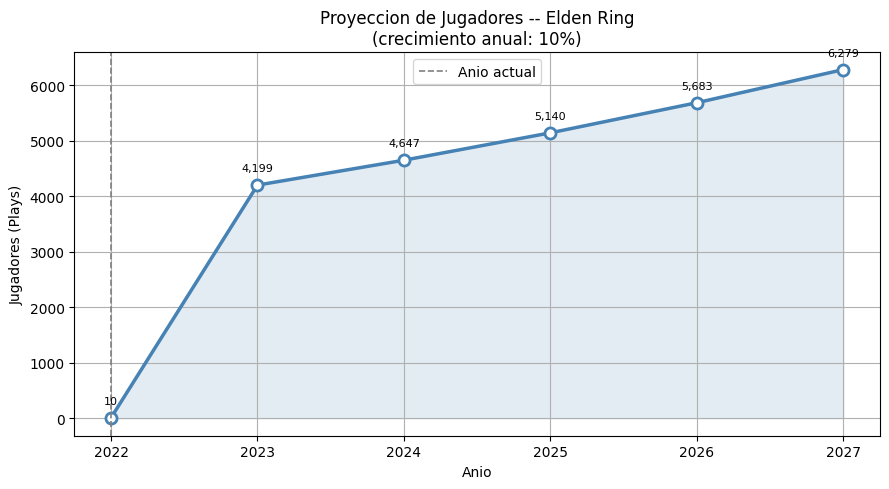

Grafica guardada en Drive: prediccion_futura.png


In [ ]:
# Grafica de proyeccion de jugadores futuros
all_years = [current_year] + future_years
all_plays = [current_plays] + future_plays

pyplot.figure(figsize=(9, 5))
pyplot.plot(all_years, all_plays, 'o-', color='steelblue',
            linewidth=2.5, markersize=8,
            markerfacecolor='white', markeredgewidth=2)
pyplot.fill_between(all_years, all_plays, alpha=0.15, color='steelblue')
pyplot.axvline(current_year, color='gray', linestyle='--',
               linewidth=1.2, label='Anio actual')

for yr, fp in zip(all_years, all_plays):
    pyplot.annotate('{:,.0f}'.format(fp), (yr, fp),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8)

pyplot.xlabel('Anio')
pyplot.ylabel('Jugadores (Plays)')
pyplot.title('Proyeccion de Jugadores -- {}\n(crecimiento anual: {:.0f}%)'.format(
    found_title, GROWTH_RATE * 100))
pyplot.legend()
pyplot.grid(True)
pyplot.tight_layout()
pyplot.savefig('/content/gdrive/MyDrive/prediccion_futura.png',
               dpi=150, bbox_inches='tight')
pyplot.show()
print('Grafica guardada en Drive: prediccion_futura.png')

## Parte 11: Metricas del modelo

Evaluamos que tan bien predice el modelo sobre los datos de entrenamiento.

Shape X_ne_norm: (24853, 20)
Theta calculado: [ 4.03912125e+00  2.88302857e-01 -3.81106844e-01  2.12175351e-01
 -1.12850516e-02  8.06349308e-01  2.76492736e-01 -1.41560932e-01
  3.56450488e-01 -7.30119672e-04  1.20656921e-01  9.59897574e-02
  1.13808180e-01  5.45009489e-17  5.34623314e-02  2.30374490e-18
  0.00000000e+00 -1.35146922e-02  1.12063356e-01  1.58205386e-01]
Metricas del modelo (escala logaritmica):
  R2   : 0.4734  (47.3% de varianza explicada)
  RMSE : 1.3776 (en escala log)
  MAE  : 1.1291 (en escala log)


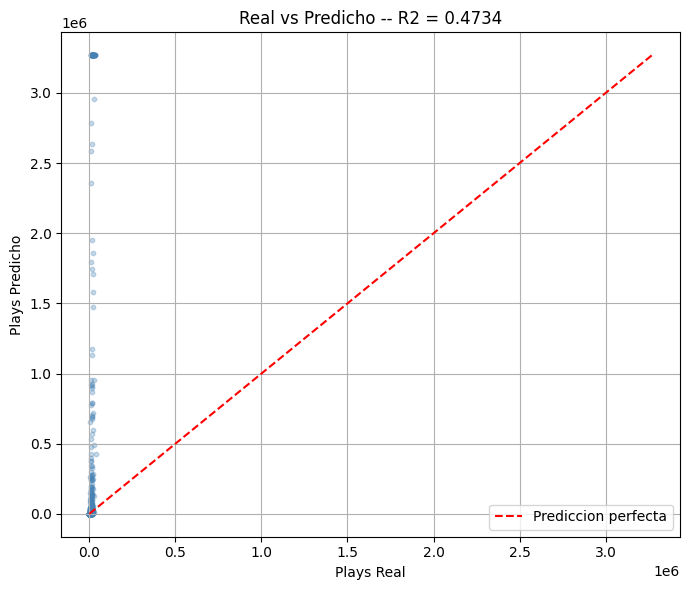

In [ ]:
# Predicciones sobre todos los datos (ecuacion normal)
# X sin normalizar + columna de unos
X_ne = np.concatenate([np.ones((m, 1)), X], axis=1)

# Normalizar X_ne por separado para la ecuacion normal
X_ne_norm, mu_ne, sigma_ne = featureNormalize(X[: , :])
X_ne_norm = np.concatenate([np.ones((m, 1)), X_ne_norm], axis=1)

# y ya esta en log (se aplico log1p antes)
theta_ne = normalEqn(X_ne_norm, y)

print('Shape X_ne_norm: {}'.format(X_ne_norm.shape))
print('Theta calculado: {}'.format(theta_ne))

# Prediccion en escala log
y_pred_log = np.dot(X_ne_norm, theta_ne)

# Recortar valores extremos (log de plays no puede ser negativo ni mayor a ~15)
y_pred_log = np.clip(y_pred_log, 0, 15)

# Metricas en escala log (mas estables)
ss_res = np.sum((y - y_pred_log) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(np.mean((y - y_pred_log) ** 2))
mae    = np.mean(np.abs(y - y_pred_log))

print('Metricas del modelo (escala logaritmica):')
print('  R2   : {:.4f}  ({:.1f}% de varianza explicada)'.format(r2, r2 * 100))
print('  RMSE : {:.4f} (en escala log)'.format(rmse))
print('  MAE  : {:.4f} (en escala log)'.format(mae))

# Revertir solo para la grafica
y_pred_real = np.expm1(y_pred_log)
y_real      = np.expm1(y)

# Grafica Real vs Predicho
pyplot.figure(figsize=(7, 6))
pyplot.scatter(y_real, y_pred_real, alpha=0.3, s=10, color='steelblue')
lim = max(float(y_real.max()), float(y_pred_real.max()))
pyplot.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Prediccion perfecta')
pyplot.xlabel('Plays Real')
pyplot.ylabel('Plays Predicho')
pyplot.title('Real vs Predicho -- R2 = {:.4f}'.format(r2))
pyplot.legend()
pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()